In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from PIL import Image

# Camera selection.
#
# Every USB camera registers TWO /dev/video* nodes: a capture node and a
# metadata node that cannot stream (sysfs "index" = 0 and 1). Minor numbers are
# handed out in plug order, so they shift whenever you replug - the C270 was
# video4, the Dino-Lite came up as video5. Don't hardcode a number; match the
# device name instead. Substring, case-insensitive; None = first camera found.
CAM_NAME = "dino"          # "dino", "c270", "acer", or None

def list_cameras():
    """[(index, name)] for every V4L2 capture node (metadata nodes excluded)."""
    found = []
    for path in sorted(glob.glob("/sys/class/video4linux/video*")):
        try:
            with open(os.path.join(path, "index")) as f:
                if int(f.read()) != 0:          # 1 = metadata node, can't stream
                    continue
            with open(os.path.join(path, "name")) as f:
                found.append((int(os.path.basename(path)[5:]), f.read().strip()))
        except OSError:
            continue
    return found

_last_cap = []          # release stale handles: a cell interrupted before
                        # cap.release() leaves a VideoCapture bound to a node
                        # that may vanish on replug ("failed VIDIOC_REQBUFS:
                        # errno=19 No such device" from the old object).

def open_camera(name=None, index=None):
    """Open a camera by name substring (default CAM_NAME), or by explicit index."""
    while _last_cap:
        _last_cap.pop().release()
    cameras = list_cameras()
    if index is None:
        want = CAM_NAME if name is None else name
        matches = [i for i, n in cameras if want is None or want.lower() in n.lower()]
        if not matches:
            raise RuntimeError("no camera matching {0!r}; found {1}".format(want, cameras))
        index = matches[0]

    cap = cv2.VideoCapture(index, cv2.CAP_V4L2)   # pinned: no silent FFMPEG fallback
    if cap.isOpened() and cap.read()[0]:
        print("opened /dev/video{0}: {1}".format(index, dict(cameras).get(index, "?")))
        _last_cap.append(cap)
        return cap
    cap.release()
    raise RuntimeError("/dev/video{0} won't stream (already open in another cell?); "
                       "capture nodes: {1}".format(index, cameras))

list_cameras()

[]

# 1: camera intrinsics calibration

In [24]:
# ChArUco board:
COLS, ROWS = 6, 8                       # squares across, down
square_len = 0.03                      # 30 mm squares, in metres
marker_len = 0.0225                     # 22.5 mm markers (must be < square)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100)
board = cv2.aruco.CharucoBoard((COLS, ROWS), square_len, marker_len, aruco_dict)
MARGIN = 60
cv2.imwrite("charuco_6x8.png", board.generateImage((960 + 2 * MARGIN, 1280 + 2 * MARGIN), marginSize=MARGIN))

True

In [25]:
def calibrate_camera_intrinsic(image_filenames):
    detector = cv2.aruco.CharucoDetector(board)   # sub-pixel refines internally
    all_obj, all_img = [], []
    image_resolution = None

    for img_file in sorted(image_filenames):
        img = cv2.imread(img_file)
        if img is None:
            print("=> unreadable: {0}".format(img_file))
            continue
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        wh = img_gray.shape[:2][::-1]   # converts numpy (h, w) to (w, h)
        if image_resolution is None:
            image_resolution = wh
        elif wh != image_resolution:
            raise ValueError("{0}: size {1} != {2}".format(img_file, wh, image_resolution))

        corners, ids, _, _ = detector.detectBoard(img_gray)
        n = 0 if corners is None else len(corners)

        if n < 6:                       # too few (or none) to pose the board - skip
            continue
        
        objPoints, imgPoints = board.matchImagePoints(corners, ids)
        all_obj.append(objPoints)
        all_img.append(imgPoints)

    if len(all_obj) < 4:
        raise RuntimeError("only {0} usable views; aim for 20+".format(len(all_obj)))

    # Default 5-coefficient model (k1,k2,p1,p2,k3). CALIB_RATIONAL_MODEL adds 3
    # more radial terms but overfits unless many views reach the image border.
    (ret, camera_matrix, distortion_coefficients,
     rotation_vectors, translation_vectors) = cv2.calibrateCamera(
        all_obj, all_img, image_resolution, None, None)

    print('views used:', len(all_obj))
    print('ret (RMS reprojection, px):', ret)   # want < 0.5
    print('camera_matrix:', camera_matrix)
    print('distortion_coefficients:', distortion_coefficients.ravel())
    return True, camera_matrix, distortion_coefficients

def detect_calib_board(image_rgb, camera_matrix, dist_coeffs):
    output_img_rgb = image_rgb.copy()
    grey = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    detector = cv2.aruco.CharucoDetector(board)
    corners, chIds, mCorners, mIds = detector.detectBoard(grey)
    if corners is None or len(corners) < 4:
        print('Error: Could not identify the calibration board in the image!')
        return False, None, None, output_img_rgb

    # OpenCV 5 returns flat (N,2)/(N,) arrays; the drawing helpers want (N,1,*)
    if mIds is not None and len(mIds):
        cv2.aruco.drawDetectedMarkers(output_img_rgb, mCorners,
                                      np.asarray(mIds).reshape(-1, 1))
    cv2.aruco.drawDetectedCornersCharuco(output_img_rgb,
                                         np.asarray(corners).reshape(-1, 1, 2),
                                         np.asarray(chIds).reshape(-1, 1))

    objPoints, imgPoints = board.matchImagePoints(corners, chIds)
    ret_val, board_rvec_rdg, board_tvec = cv2.solvePnP(
        objPoints, imgPoints, camera_matrix, dist_coeffs)
    if not ret_val:
        print('Error: Could not identity the pose of the calibration board in the image!')
        return False, None, None, output_img_rgb

    print('Board rvec: ')
    print(board_rvec_rdg)
    print('Board tvec: ')
    print(board_tvec)

    length_of_axis = 0.05          # metres; ~1.7 squares, visible at 30 mm pitch
    cv2.drawFrameAxes(output_img_rgb, camera_matrix, dist_coeffs,
                      board_rvec_rdg, board_tvec, length_of_axis)
    plt.imshow(output_img_rgb)
    plt.show()
    return True, board_rvec_rdg, board_tvec, output_img_rgb

In [26]:
image_files = sorted(glob.glob("board_images/*.jpeg"))
calibrated, camera_matrix, distortion_coefficients = calibrate_camera_intrinsic(image_files)

# Cache it so later cells (and other scripts) don't have to recalibrate:
np.savez("camera_intrinsics.npz",
         camera_matrix=camera_matrix, dist_coeffs=distortion_coefficients)
# reload with: d = np.load("camera_intrinsics.npz");
#              camera_matrix, distortion_coefficients = d["camera_matrix"], d["dist_coeffs"]

views used: 22
ret (RMS reprojection, px): 0.37937808340344714
camera_matrix: [[1.41211976e+03 0.00000000e+00 4.64882483e+02]
 [0.00000000e+00 1.41287277e+03 3.53466231e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distortion_coefficients: [ 0.09767632  0.34883782  0.00457647 -0.0081482  -2.02924257]


Board rvec: 
[[ 0.28719962]
 [-0.25108619]
 [ 1.53830058]]
Board tvec: 
[[ 0.12124572]
 [-0.08129213]
 [ 0.50459804]]


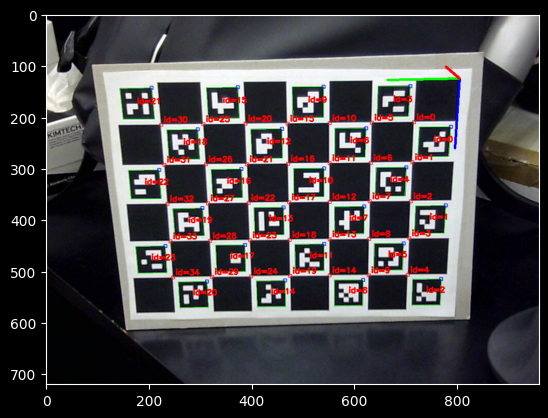

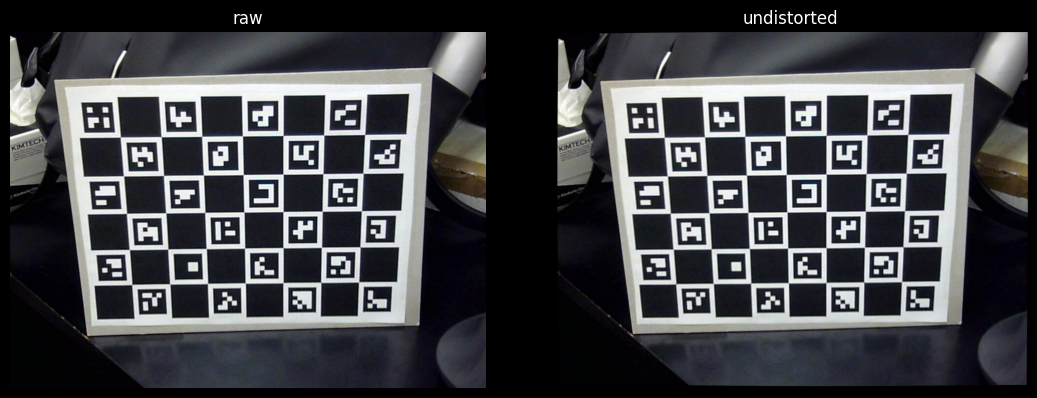

In [27]:
# Sanity check: board pose on one view + before/after undistortion
img_rgb = cv2.cvtColor(cv2.imread(image_files[1]), cv2.COLOR_BGR2RGB)
ok, rvec, tvec, drawn = detect_calib_board(img_rgb, camera_matrix, distortion_coefficients)

undistorted = cv2.undistort(img_rgb, camera_matrix, distortion_coefficients)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img_rgb);      ax[0].set_title("raw");         ax[0].axis("off")
ax[1].imshow(undistorted);  ax[1].set_title("undistorted"); ax[1].axis("off")
plt.tight_layout(); plt.show()

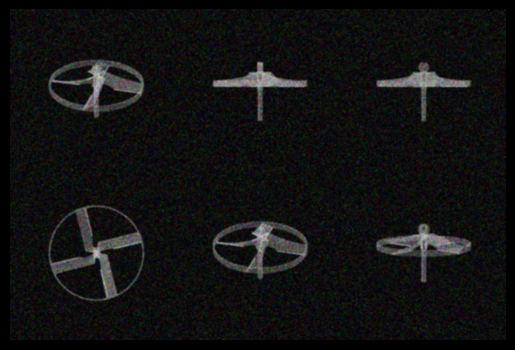

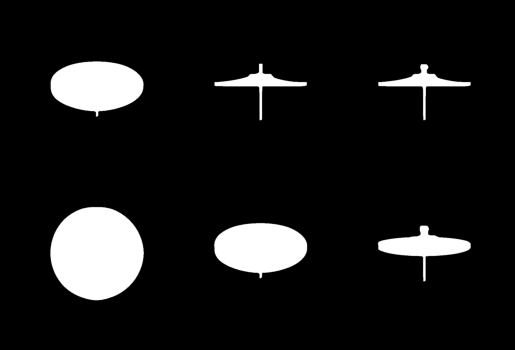

In [ ]:
# Colour segmentation in HSV.
#
# OpenCV hue is 0-179 (degrees / 2), S and V are 0-255. The S/V floors are what
# keep white walls and dark corners out of the mask - tune those before hue.
# Red straddles hue 0, so it needs two windows OR'd together; green and blue
# sit mid-range and need only one.
from turtle import width


HSV_RANGES = {
    "red":   [((  0, 120, 70), ( 10, 255, 255)),    # low side of the wrap
              ((170, 120, 70), (179, 255, 255))],   # high side
    "green": [(( 40,  80, 60), ( 85, 255, 255))],
    "blue":  [((100,  80, 60), (130, 255, 255))],
    "white":  [((0,  0, 40), (179, 255, 255))],
}

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10))

def colour_mask(frame_bgr, colour):
    """Binary mask (0 / 255) of one named colour in HSV_RANGES."""
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    mask = None
    for lo, hi in HSV_RANGES[colour]:
        m = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
        mask = m if mask is None else cv2.bitwise_or(mask, m)
        
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled = np.zeros_like(mask)
    cv2.drawContours(filled, contours, -1, 255, thickness=cv2.FILLED)  # -1 = all, FILLED
        
    mask = cv2.morphologyEx(filled, cv2.MORPH_OPEN, kernel)    # drop speckle
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)   # fill pinholes
    
    mask = cv2.erode(mask, kernel, iterations=1)   # no dilate-back
    
    
    d = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    while True:
        grown = cv2.bitwise_and(cv2.dilate(mask, d), mask)  # dilate, then clip to mask
        if np.array_equal(grown, mask):
            break
        mask = grown
        
    return mask

def largest_blob(mask, min_area=200):
    """Biggest contour in a mask, or None. This is what you feed to the SVD pose cell."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    return cnt if cv2.contourArea(cnt) >= min_area else None



In [ ]:

# img = cv2.imread('./drone_orientation/drone1.jpeg')   # numpy array, BGR

img = cv2.imread('./renders/drone_render.png')   # numpy array, BGR
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# downsample image:
img_ratio = img.shape[0] / img.shape[1]   # (w, h)

img_720p = cv2.resize(img, (1280, round(1280 * img_ratio)), interpolation=cv2.INTER_AREA) 
img_480p = cv2.resize(img, (640, round(640 * img_ratio)), interpolation=cv2.INTER_AREA) 

img = img_480p

# add_gaussian_noise:
noise = np.random.normal(0, 35, img.shape).astype(np.float32)
img = cv2.add(img.astype(np.float32), noise)
img = np.clip(img, 0, 255).astype(np.uint8)

# gaussian blur:
img = cv2.GaussianBlur(img, (3, 3), 0)


plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))          # convert BGR -> RGB
plt.axis('off')
plt.show()

mask = colour_mask(hsv, "white")

plt.imshow(cv2.cvtColor(mask, cv2.COLOR_BGR2RGB))          # convert BGR -> RGB
plt.axis('off')
plt.show()

blob 0: centroid=(340.6, 958.5)  area=104712
blob 1: centroid=(983.9, 937.3)  area=56896
blob 2: centroid=(340.3, 302.4)  area=56886
blob 3: centroid=(1627.5, 931.0)  area=25062
blob 4: centroid=(1626.0, 289.7)  area=12746
blob 5: centroid=(982.3, 291.6)  area=12336


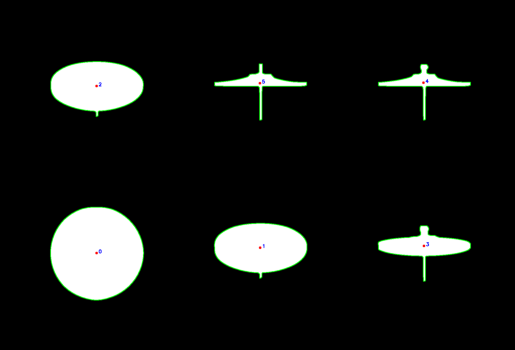

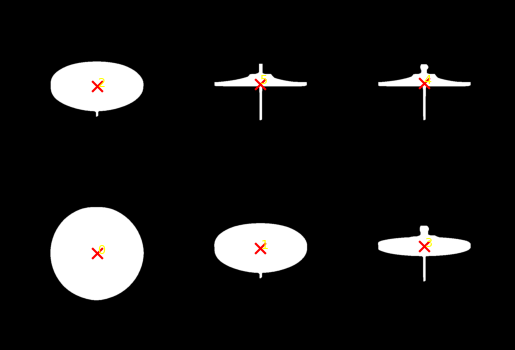

In [30]:
def contour_centroids(mask, min_area=200):
    """Return [(cx, cy, area, contour), ...] sorted largest-first."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs = []
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area:                      # drop speckle
            continue
        M = cv2.moments(c)
        if M["m00"] == 0:                        # degenerate (zero-area) contour
            continue
        cx = M["m10"] / M["m00"]                 # centroid x = sum(x)/area
        cy = M["m01"] / M["m00"]                 # centroid y = sum(y)/area
        blobs.append((cx, cy, area, c))
    blobs.sort(key=lambda b: b[2], reverse=True) # sort by area, biggest first
    return blobs


vis = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
for rank, (cx, cy, area, c) in enumerate(contour_centroids(mask)):
    cv2.drawContours(vis, [c], -1, (0, 255, 0), 2)                    # outline
    cv2.circle(vis, (int(cx), int(cy)), 5, (0, 0, 255), -1)          # centroid dot
    cv2.putText(vis, str(rank), (int(cx) + 8, int(cy)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)       # rank label
    print(f"blob {rank}: centroid=({cx:.1f}, {cy:.1f})  area={area:.0f}")

plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()

blobs = contour_centroids(mask)
xs = [b[0] for b in blobs]
ys = [b[1] for b in blobs]

plt.imshow(mask, cmap="gray")
plt.scatter(xs, ys, c="red", s=60, marker="x")
for rank, (cx, cy, *_ ) in enumerate(blobs):
    plt.annotate(str(rank), (cx, cy), color="yellow", fontsize=9)
plt.axis("off"); plt.show()


In [ ]:
import serial
import time

SERIAL_PORT = '/dev/ttyUSB0'
BAUD_RATE = 9600

try:
    # Open the connection with a 1-second read timeout
    ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout=1)
    time.sleep(2) # Wait for connection to initialize
    print(f"Connected to {SERIAL_PORT} at {BAUD_RATE} baud.")

    while True:
        if ser.in_waiting > 0:
            # Read a line, decode bytes to string, and remove whitespace/newlines
            line = ser.readline().decode('utf-8').rstrip()
            print(line)
            
except KeyboardInterrupt:
    print("\nProgram interrupted by user.")
except Exception as e:
    print(f"Error: {e}")
finally:
    if 'ser' in locals() and ser.is_open:
        ser.close()
        print("Serial port closed.")

ModuleNotFoundError: No module named 'serial'